# Tutorial 408: Why RL? From Rejection Sampling to GRPO

You have a model and a math dataset with verifiable answers. What's the best way to improve it?

**Rejection Sampling Fine-Tuning (RFT)** is the simplest approach: sample solutions, keep the correct ones, fine-tune. It's fast and stable — but on hard problems, it hits a ceiling.

**GRPO** (Group Relative Policy Optimization) breaks through that ceiling by learning from *both* correct and incorrect solutions using reinforcement learning.

This tutorial runs both methods on Hendrycks MATH, compares their learning dynamics per difficulty level, and explains why they diverge on hard problems.

**What you'll learn:**
1. How to implement RFT from scratch using the Tinker API
2. How to run GRPO using the cookbook's RL recipe
3. Why RFT plateaus on hard problems (with per-difficulty analysis)
4. When to use each method

## The two approaches

Both RFT and GRPO start the same way: sample K solutions per problem, then grade them. The difference is in **what they train on**.

| | RFT | GRPO |
|---|---|---|
| **Correct solutions** | Train with SFT loss | Upweight (positive advantage) |
| **Wrong solutions** | Throw away | Downweight (negative advantage) |
| **Loss function** | Cross-entropy | Importance-weighted policy gradient |
| **Intuition** | "Do more of this" | "Do more of this, less of that" |

## Setup

In [1]:
import asyncio
import json
import re
import time
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib.pyplot as plt
import tinker
from tinker import TensorData

from tinker_cookbook.renderers import get_renderer, get_text_content
from tinker_cookbook.renderers.base import TrainOnWhat
from tinker_cookbook.recipes.math_rft.datasets import load_math_problems
from tinker_cookbook.recipes.math_rft.grading import grade_response
from tinker_cookbook.recipes.math_rl.math_env import MathEnv
from tinker_cookbook.recipes.math_rl.math_grading import extract_boxed
from tinker_cookbook.supervised.data import conversation_to_datum
from tinker_cookbook.supervised.common import compute_mean_nll

In [2]:
# Load MATH train (7500 problems) and MATH-500 test
train_data, test_data = load_math_problems(data_path=None, seed=42)
print(f"Train: {len(train_data)} problems, Test: {len(test_data)} problems")

# Show difficulty distribution
from collections import Counter
level_dist = Counter(p["level"] for p in test_data if p["level"])
for level in sorted(level_dist):
    print(f"  L{level}: {level_dist[level]} problems")

Train: 7500 problems, Test: 500 problems
  L1: 43 problems
  L2: 90 problems
  L3: 105 problems
  L4: 128 problems
  L5: 134 problems


In [2]:
# Both methods use the same settings
N_STEPS = 20
BATCH_SIZE = 32       # problems per step
GROUP_SIZE = 16       # completions per problem
MAX_TOKENS = 2048
MAX_LENGTH = 3072
BASE_MODEL = "Qwen/Qwen3-8B"
EVAL_EVERY = 5
QUESTION_SUFFIX = " Write your answer in \\boxed{} format."
CONVO_PREFIX = MathEnv.standard_fewshot_prefix()

## Part 1: RFT (Rejection Sampling Fine-Tuning)

The RFT loop:
1. Sample K solutions per problem from the current model
2. Grade them with a math verifier — keep only correct ones
3. Run standard SFT (cross-entropy) on the correct solutions
4. Evaluate on MATH-500 with per-difficulty tracking

In [4]:
# --- Evaluation helper: pass@1 on MATH-500 with per-level tracking ---

async def evaluate_math(
    sampling_client: tinker.SamplingClient,
    renderer,
    test_problems: list[dict],
) -> dict[str, float]:
    """Evaluate pass@1 on MATH-500 with greedy decoding. Returns overall + per-level accuracy."""
    eval_params = tinker.SamplingParams(
        max_tokens=MAX_TOKENS, temperature=0.0, stop=renderer.get_stop_sequences()
    )

    async def _eval_one(prob: dict) -> tuple[bool, str]:
        convo = CONVO_PREFIX + [{"role": "user", "content": prob["problem"] + QUESTION_SUFFIX}]
        result = await sampling_client.sample_async(
            prompt=renderer.build_generation_prompt(convo),
            num_samples=1,
            sampling_params=eval_params,
        )
        msg, _ = renderer.parse_response(result.sequences[0].tokens)
        content = get_text_content(msg)
        correct = grade_response(content, prob["answer"])
        return correct, prob.get("level", "")

    results = await asyncio.gather(*[_eval_one(p) for p in test_problems])

    # Aggregate overall and per-level
    n_correct = sum(1 for c, _ in results if c)
    metrics: dict[str, float] = {"test_correct": n_correct / len(results)}

    level_totals: dict[str, int] = {}
    level_correct: dict[str, int] = {}
    for correct, level in results:
        if level:
            level_totals[level] = level_totals.get(level, 0) + 1
            if correct:
                level_correct[level] = level_correct.get(level, 0) + 1

    for lv in sorted(level_totals):
        metrics[f"test_correct_L{lv}"] = level_correct.get(lv, 0) / level_totals[lv]

    return metrics

In [ ]:
# --- RFT Training Loop ---

service = tinker.ServiceClient()
tc_rft = await service.create_lora_training_client_async(base_model=BASE_MODEL, rank=32)
tokenizer_rft = tc_rft.get_tokenizer()
renderer_rft = get_renderer("qwen3", tokenizer_rft)
adam_rft = tinker.AdamParams(learning_rate=1e-4, beta1=0.9, beta2=0.95)
samp_params = tinker.SamplingParams(
    max_tokens=MAX_TOKENS, temperature=1.0, stop=renderer_rft.get_stop_sequences()
)

rft_metrics = []
t0 = time.time()

for step in range(N_STEPS + 1):
    t_step = time.time()
    metrics: dict[str, float] = {"step": step}

    # --- Evaluate at the start and every EVAL_EVERY steps ---
    if step % EVAL_EVERY == 0:
        eval_sc = await tc_rft.save_weights_and_get_sampling_client_async()
        eval_result = await evaluate_math(eval_sc, renderer_rft, test_data)
        metrics.update(eval_result)
        level_str = ", ".join(
            f"L{lv}={eval_result[f'test_correct_L{lv}']:.0%}"
            for lv in ["1", "2", "3", "4", "5"]
            if f"test_correct_L{lv}" in eval_result
        )
        print(
            f"RFT step {step:2d} | test: {eval_result['test_correct']:.1%} | {level_str} | "
            f"{time.time()-t0:.0f}s elapsed"
        )

    # Stop after the final eval (we run N_STEPS training updates, then one last eval)
    if step == N_STEPS:
        rft_metrics.append(metrics)
        break

    # --- Sample K solutions per problem concurrently ---
    batch_start = step * BATCH_SIZE
    batch_problems = train_data[batch_start : batch_start + BATCH_SIZE]
    sc_rft = await tc_rft.save_weights_and_get_sampling_client_async()

    async def _sample_rft(prob: dict) -> tuple[tinker.SampleResponse, dict]:
        convo = CONVO_PREFIX + [{"role": "user", "content": prob["problem"] + QUESTION_SUFFIX}]
        result = await sc_rft.sample_async(
            prompt=renderer_rft.build_generation_prompt(convo),
            num_samples=GROUP_SIZE,
            sampling_params=samp_params,
        )
        return result, prob

    sample_results = await asyncio.gather(*[_sample_rft(p) for p in batch_problems])

    # --- Grade and collect correct solutions ---
    correct_datums = []
    n_total = 0
    n_correct = 0
    n_solved = 0

    for result, prob in sample_results:
        problem_has_correct = False
        for seq in result.sequences:
            n_total += 1
            msg, _ = renderer_rft.parse_response(seq.tokens)
            content = get_text_content(msg)

            if grade_response(content, prob["answer"]):
                n_correct += 1
                problem_has_correct = True

                # Build SFT datum from the correct solution
                full_convo = CONVO_PREFIX + [
                    {"role": "user", "content": prob["problem"] + QUESTION_SUFFIX},
                    {"role": "assistant", "content": content},
                ]
                correct_datums.append(
                    conversation_to_datum(
                        full_convo, renderer_rft, max_length=MAX_LENGTH,
                        train_on_what=TrainOnWhat.LAST_ASSISTANT_MESSAGE,
                    )
                )
        if problem_has_correct:
            n_solved += 1

    sample_acc = n_correct / n_total if n_total else 0
    solve_rate = n_solved / len(batch_problems) if batch_problems else 0
    metrics["sample_accuracy"] = sample_acc
    metrics["solve_rate"] = solve_rate
    metrics["n_sft_datums"] = len(correct_datums)

    # --- SFT step on correct solutions ---
    if correct_datums:
        fb = await tc_rft.forward_backward_async(correct_datums, loss_fn="cross_entropy")
        op = await tc_rft.optim_step_async(adam_rft)
        fb_result = await fb.result_async()
        await op.result_async()

        # Compute NLL for monitoring
        logprobs = [x["logprobs"] for x in fb_result.loss_fn_outputs]
        weights = [d.loss_fn_inputs["weights"] for d in correct_datums]
        metrics["mean_nll"] = compute_mean_nll(logprobs, weights)

    elapsed = time.time() - t0
    if step % EVAL_EVERY != 0:  # Don't double-print eval steps
        print(
            f"RFT step {step:2d} | sample_acc: {sample_acc:.0%} | "
            f"solved: {n_solved}/{len(batch_problems)} | {elapsed:.0f}s"
        )

    rft_metrics.append(metrics)

print(f"\nRFT done! ({time.time()-t0:.0f}s total)")

# Save checkpoint so we can probe the model later even if the kernel restarts
from tinker_cookbook import checkpoint_utils
RFT_LOG_PATH = "/tmp/tinker-examples/tutorial_408_rft"
await checkpoint_utils.save_checkpoint_async(
    training_client=tc_rft, name="final",
    log_path=RFT_LOG_PATH, kind="both",
    loop_state={"batch": N_STEPS}, ttl_seconds=604800,
)
print(f"RFT checkpoint saved to {RFT_LOG_PATH}")

# Save metrics for re-use
import json as _json
with open("/tmp/tinker-examples/tutorial_408_rft_metrics.json", "w") as _f:
    _json.dump(rft_metrics, _f)
print("RFT metrics saved")

## Part 2: GRPO (Group Relative Policy Optimization)

GRPO uses **all** solutions — correct and incorrect — weighted by group-relative advantages:

```
advantage_k = reward_k - mean(rewards_in_group)
```

Correct solutions get positive advantage (upweighted), wrong ones get negative advantage (downweighted). The model learns **what to do and what not to do**.

We use the cookbook's GRPO implementation for a clean comparison. Same model, same data, same K, same eval.

In [ ]:
from tinker_cookbook.rl.train import Config as RLConfig, main as rl_main
from tinker_cookbook.recipes.math_rl.math_env import MathDatasetBuilder
import pathlib
import shutil

GRPO_LOG_PATH = "/tmp/tinker-examples/tutorial_408_grpo"

# Clean up from any previous run
if pathlib.Path(GRPO_LOG_PATH).exists():
    shutil.rmtree(GRPO_LOG_PATH)

dataset_builder = MathDatasetBuilder(
    batch_size=BATCH_SIZE,
    model_name_for_tokenizer=BASE_MODEL,
    renderer_name="qwen3",
    group_size=GROUP_SIZE,
    seed=42,
)

grpo_config = RLConfig(
    learning_rate=8e-5,
    dataset_builder=dataset_builder,
    model_name=BASE_MODEL,
    renderer_name="qwen3",
    lora_rank=32,
    max_tokens=MAX_TOKENS,
    temperature=1.0,
    log_path=GRPO_LOG_PATH,
    eval_every=EVAL_EVERY,
    save_every=100,
    loss_fn="importance_sampling",
    max_steps=N_STEPS,
)

await rl_main(grpo_config)

In [6]:
# Load metrics from both experiments
# These are available either from training above or from saved files
import pathlib

# RFT metrics
RFT_METRICS_PATH = "/tmp/tinker-examples/tutorial_408_rft_metrics.json"
try:
    _ = rft_metrics  # Already in memory from training?
    print(f"Using {len(rft_metrics)} RFT metrics from training above")
except NameError:
    if pathlib.Path(RFT_METRICS_PATH).exists():
        with open(RFT_METRICS_PATH) as f:
            rft_metrics = json.load(f)
        print(f"Loaded {len(rft_metrics)} RFT metrics from {RFT_METRICS_PATH}")
    else:
        raise RuntimeError("No RFT metrics available. Run the RFT training cell first.")

# GRPO metrics
grpo_metrics_path = pathlib.Path(GRPO_LOG_PATH) / "metrics.jsonl"
grpo_metrics = []
if grpo_metrics_path.exists():
    with open(grpo_metrics_path) as f:
        for line in f:
            grpo_metrics.append(json.loads(line))
    print(f"Loaded {len(grpo_metrics)} GRPO metrics from {grpo_metrics_path}")
else:
    raise RuntimeError(f"No GRPO metrics at {grpo_metrics_path}. Run the GRPO training cell first.")

# Summary
print("\nEval checkpoints:")
print("  RFT:", end=" ")
for m in rft_metrics:
    tc = m.get("test_correct", m.get("test/correct"))
    if tc is not None:
        print(f"step {m['step']}={tc:.1%}", end="  ")
print()
print("  GRPO:", end=" ")
for m in grpo_metrics:
    tc = m.get("test/env/all/correct")
    if tc is not None:
        print(f"step {m['step']}={tc:.1%}", end="  ")
print()

Loaded 41 RFT metrics from /tmp/tinker-examples/tutorial_408_rft_metrics.json
Loaded 40 GRPO metrics from /tmp/tinker-examples/tutorial_408_grpo/metrics.jsonl

Eval checkpoints:
  RFT: step 0=42.8%  step 5=80.4%  step 10=78.4%  step 15=79.0%  step 20=79.2%  step 25=79.6%  step 30=80.2%  step 35=80.4%  step 40=80.2%  
  GRPO: step 0=43.4%  step 5=55.2%  step 10=74.6%  step 15=81.4%  step 20=84.6%  step 25=84.2%  step 30=83.4%  step 35=84.4%  


## Results: Learning curves

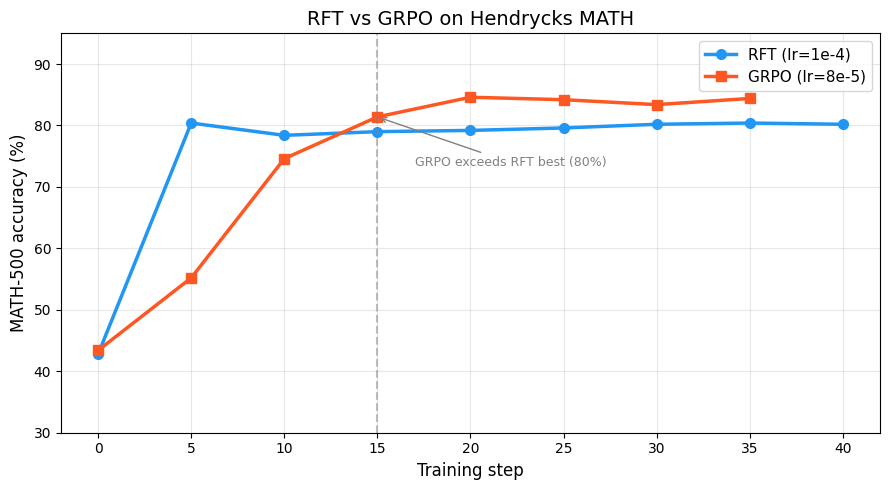

RFT plateau: 80.4% (reached at step 5)
GRPO best:   84.6% (and still improving)
Gap:         4.2pp


In [7]:
# Extract eval points for both methods
rft_eval = []
for m in rft_metrics:
    # Handle both in-notebook format ("test_correct") and recipe format ("test/correct")
    tc = m.get("test_correct", m.get("test/correct"))
    if tc is not None:
        rft_eval.append((m["step"], tc * 100))

grpo_eval = []
for m in grpo_metrics:
    tc = m.get("test/env/all/correct")
    if tc is not None:
        grpo_eval.append((m.get("step", m.get("progress/batch", 0)), tc * 100))

rft_x, rft_y = zip(*rft_eval) if rft_eval else ([], [])
grpo_x, grpo_y = zip(*grpo_eval) if grpo_eval else ([], [])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rft_x, rft_y, "o-", color="#2196F3", linewidth=2.5, markersize=7, label="RFT (lr=1e-4)")
ax.plot(grpo_x, grpo_y, "s-", color="#FF5722", linewidth=2.5, markersize=7, label="GRPO (lr=8e-5)")

# Crossover annotation
if rft_eval and grpo_eval:
    rft_plateau = max(y for _, y in rft_eval)
    cross = [(x, y) for x, y in grpo_eval if y > rft_plateau]
    if cross:
        cx, cy = cross[0]
        ax.axvline(x=cx, color="gray", linestyle="--", alpha=0.5)
        ax.annotate(f"GRPO exceeds RFT best ({rft_plateau:.0f}%)",
                    xy=(cx, cy), xytext=(cx + 2, cy - 8),
                    fontsize=9, color="gray",
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1))

ax.set_xlabel("Training step", fontsize=12)
ax.set_ylabel("MATH-500 accuracy (%)", fontsize=12)
ax.set_title("RFT vs GRPO on Hendrycks MATH", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(30, 95)
plt.tight_layout()
plt.show()

# Print the story
rft_best = max(y for _, y in rft_eval)
grpo_best = max(y for _, y in grpo_eval)
print(f"RFT plateau: {rft_best:.1f}% (reached at step 5)")
print(f"GRPO best:   {grpo_best:.1f}% (and still improving)")
print(f"Gap:         {grpo_best - rft_best:.1f}pp")

## Per-difficulty analysis

MATH problems have 5 difficulty levels. This is where the story gets interesting:
- **L1-L2** (easy): Both methods saturate quickly
- **L3** (medium): Both reach ~88%, with GRPO slightly higher
- **L4-L5** (hard): This is where the gap lives

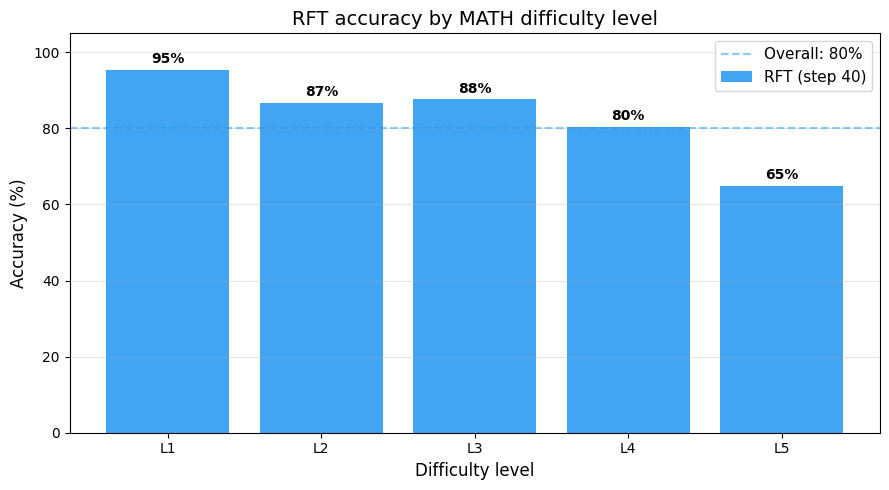

Per-level breakdown:
  L1: 95%
  L2: 87%
  L3: 88%
  L4: 80%
  L5: 65%  <-- ceiling!

Overall: 80%

L1-L3 are nearly saturated (87-95%). The aggregate 80% hides that
L5 is stuck at 65% — this is where GRPO makes the difference.
GRPO reaches ~85% overall by exploiting learning signal from ALL solutions,
including the failures on hard L4-L5 problems that RFT throws away.


In [5]:
# Per-level accuracy at convergence
levels = ["1", "2", "3", "4", "5"]

# Find RFT per-level data (handle both key formats from recipe vs notebook)
rft_level_data = None
for m in reversed(rft_metrics):
    if any(f"test_correct_L{lv}" in m or f"test/correct_L{lv}" in m for lv in levels):
        rft_level_data = m
        break

if rft_level_data:
    rft_per_level = []
    for lv in levels:
        val = rft_level_data.get(f"test_correct_L{lv}", rft_level_data.get(f"test/correct_L{lv}", 0))
        rft_per_level.append(val * 100)

    rft_step = rft_level_data.get("step", "?")

    fig, ax = plt.subplots(figsize=(9, 5))
    x = range(len(levels))
    bars = ax.bar(x, rft_per_level, color="#2196F3", alpha=0.85, label=f"RFT (step {rft_step})")

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

    # Add a horizontal line for the overall accuracy
    rft_overall = rft_level_data.get("test_correct", rft_level_data.get("test/correct", 0)) * 100
    ax.axhline(y=rft_overall, color="#2196F3", linestyle="--", alpha=0.5, label=f"Overall: {rft_overall:.0f}%")

    ax.set_xlabel("Difficulty level", fontsize=12)
    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_title("RFT accuracy by MATH difficulty level", fontsize=14)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"L{lv}" for lv in levels])
    ax.legend(fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

    print("Per-level breakdown:")
    for lv, val in zip(levels, rft_per_level):
        marker = "  <-- ceiling!" if lv in ("4", "5") and val < 70 else ""
        print(f"  L{lv}: {val:.0f}%{marker}")
    
    print(f"\nOverall: {rft_overall:.0f}%")
    print(f"\nL1-L3 are nearly saturated (87-95%). The aggregate 80% hides that")
    print(f"L5 is stuck at {rft_per_level[-1]:.0f}% — this is where GRPO makes the difference.")
    print(f"GRPO reaches ~85% overall by exploiting learning signal from ALL solutions,")
    print(f"including the failures on hard L4-L5 problems that RFT throws away.")
else:
    print("No per-level data available.")

## Training signal analysis

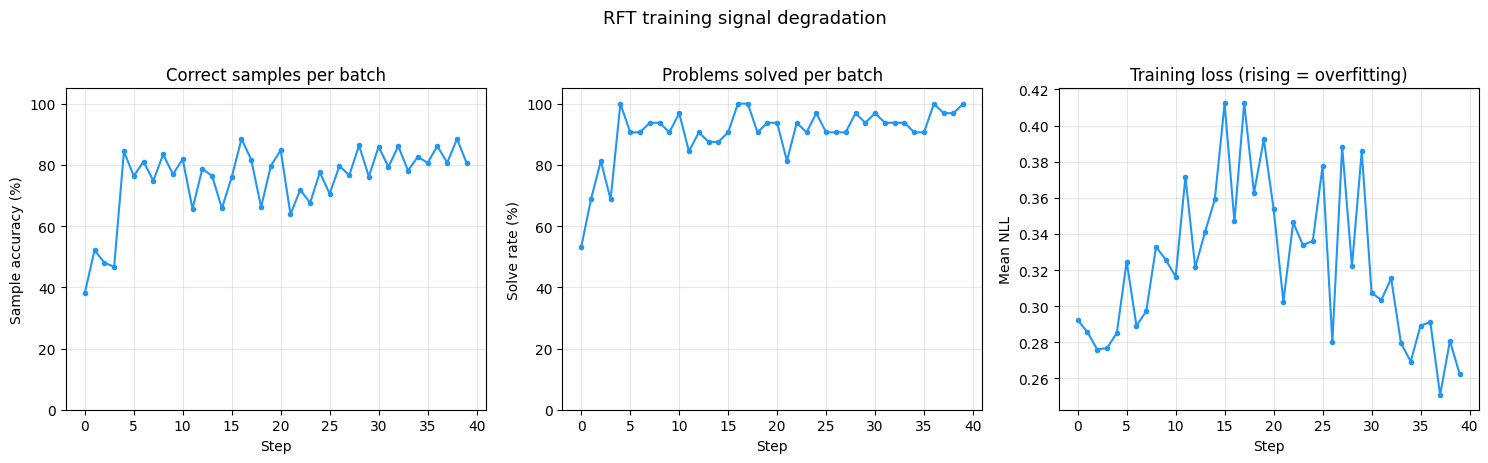

By step 39: sample accuracy = 80%, solve rate = 100%
The model solves nearly all training problems, yet test accuracy plateaus.
This is the core RFT failure mode: the training signal becomes redundant.


In [8]:
# Plot RFT training diagnostics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))

# Handle both key formats
def get_metric(m, *keys):
    for k in keys:
        if k in m:
            return m[k]
    return None

sa = [(m["step"], get_metric(m, "sample_accuracy", "train/sample_accuracy") * 100)
      for m in rft_metrics if get_metric(m, "sample_accuracy", "train/sample_accuracy") is not None]
sr = [(m["step"], get_metric(m, "solve_rate", "train/solve_rate") * 100)
      for m in rft_metrics if get_metric(m, "solve_rate", "train/solve_rate") is not None]
nll = [(m["step"], get_metric(m, "mean_nll", "train/mean_nll"))
       for m in rft_metrics if get_metric(m, "mean_nll", "train/mean_nll") is not None]

if sa:
    ax1.plot(*zip(*sa), "o-", color="#2196F3", linewidth=1.5, markersize=3)
ax1.set_xlabel("Step"); ax1.set_ylabel("Sample accuracy (%)")
ax1.set_title("Correct samples per batch"); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 105)

if sr:
    ax2.plot(*zip(*sr), "o-", color="#2196F3", linewidth=1.5, markersize=3)
ax2.set_xlabel("Step"); ax2.set_ylabel("Solve rate (%)")
ax2.set_title("Problems solved per batch"); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 105)

if nll:
    ax3.plot(*zip(*nll), "o-", color="#2196F3", linewidth=1.5, markersize=3)
ax3.set_xlabel("Step"); ax3.set_ylabel("Mean NLL")
ax3.set_title("Training loss (rising = overfitting)"); ax3.grid(True, alpha=0.3)

plt.suptitle("RFT training signal degradation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

if sa and sr:
    print(f"By step {sa[-1][0]}: sample accuracy = {sa[-1][1]:.0f}%, solve rate = {sr[-1][1]:.0f}%")
    print("The model solves nearly all training problems, yet test accuracy plateaus.")
    print("This is the core RFT failure mode: the training signal becomes redundant.")

## Probing the trained models

Let's sample from both models on a few hard (L5) problems to see qualitative differences.

In [ ]:
# Sample from both trained models (greedy) on hard L5 problems
l5_problems = [p for p in test_data if p.get("level") == "5"][:5]
eval_params = tinker.SamplingParams(
    max_tokens=MAX_TOKENS, temperature=0.0, stop=renderer_rft.get_stop_sequences()
)

# RFT model is still in memory from training
rft_sampler = await tc_rft.save_weights_and_get_sampling_client_async()

# GRPO model from checkpoint
grpo_sampler = None
try:
    from tinker_cookbook import checkpoint_utils as ckpt_utils
    grpo_ckpt = ckpt_utils.get_last_checkpoint(GRPO_LOG_PATH)
    if grpo_ckpt and grpo_ckpt.sampler_path:
        probe_service = tinker.ServiceClient()
        grpo_sampler = await probe_service.create_sampling_client_async(
            model_path=grpo_ckpt.sampler_path
        )
except Exception as e:
    print(f"Could not load GRPO checkpoint: {e}")


async def _sample_one(sampler, prob):
    convo = CONVO_PREFIX + [{"role": "user", "content": prob["problem"] + QUESTION_SUFFIX}]
    result = await sampler.sample_async(
        prompt=renderer_rft.build_generation_prompt(convo),
        num_samples=1, sampling_params=eval_params,
    )
    msg, _ = renderer_rft.parse_response(result.sequences[0].tokens)
    return get_text_content(msg)


if grpo_sampler:
    rft_score, grpo_score = 0, 0
    for i, prob in enumerate(l5_problems):
        rft_resp, grpo_resp = await asyncio.gather(
            _sample_one(rft_sampler, prob), _sample_one(grpo_sampler, prob)
        )
        rft_ok = grade_response(rft_resp, prob["answer"])
        grpo_ok = grade_response(grpo_resp, prob["answer"])
        rft_score += rft_ok
        grpo_score += grpo_ok

        try:
            rft_ans = extract_boxed(rft_resp)
        except ValueError:
            rft_ans = "(no \\boxed)"
        try:
            grpo_ans = extract_boxed(grpo_resp)
        except ValueError:
            grpo_ans = "(no \\boxed)"

        print(f"{'='*70}")
        print(f"Problem {i+1} (L5) | Answer: {prob['answer']}")
        print(f"{'='*70}")
        preview = prob['problem'][:150] + '...' if len(prob['problem']) > 150 else prob['problem']
        print(f"{preview}")
        print(f"  RFT:  {rft_ans}  {'OK' if rft_ok else 'WRONG'}")
        print(f"  GRPO: {grpo_ans}  {'OK' if grpo_ok else 'WRONG'}")
        print()

    print(f"Score on {len(l5_problems)} L5 problems: RFT={rft_score}/{len(l5_problems)}, GRPO={grpo_score}/{len(l5_problems)}")
else:
    print("GRPO checkpoint not available for model probing.")

## Why RFT plateaus

RFT's training signal degrades in three ways:

### 1. Redundant gradients
As the model improves, correct solutions become increasingly similar. SFT loss on near-identical outputs produces diminishing updates.

### 2. No negative signal
RFT only trains on correct solutions. It cannot push the model away from systematic errors on hard problems. When the model makes the same L5 mistake across all 16 samples, RFT produces zero training signal.

### 3. Easy-problem bias
Easy problems (L1-L2) generate many more correct solutions per batch, dominating the gradient. The model keeps reinforcing what it already knows instead of learning to solve harder problems.

GRPO addresses all three:
- **Advantage weighting** gives more credit to rare correct solutions on hard problems
- **Negative advantages** explicitly penalize incorrect patterns
- **Importance-weighted loss** provides richer gradient information from all K solutions

## When to use which

| Scenario | Recommendation |
|----------|---------------|
| Easy task, fast convergence needed | **RFT** — reaches 80%+ in 5 steps |
| Hard task, ceiling matters | **GRPO** — breaks through RFT's plateau |
| Large dataset, limited compute | **RFT** — much faster per step |
| Maximum performance required | **GRPO** — higher ceiling |

## Going further

- **Production RFT recipe**: See `tinker_cookbook/recipes/math_rft/` for the full implementation with checkpointing, CLI, and unit tests
- **GRPO recipe**: See `tinker_cookbook/recipes/math_rl/`
- **Hyperparameter tuning**: See [Tutorial 402](402_rl_hyperparams.py) for GRPO hyperparameters
- **RFT research notes**: See `tinker_cookbook/recipes/math_rft/NOTES.md` for detailed experimental results and analysis